# 🌿 Blue Vision — Kalba Mangrove Monitoring

## Arab Youth Space Hackathon: 813 Challenge

This Proof of Concept uses open Sentinel-2 satellite imagery to monitor changes in mangrove extent and vegetation condition in Kalba, UAE, from 2016 to 2025.

---

## Project Objective

We want to monitor changes in mangrove extent and vegetation condition in Kalba between 2016 and 2025 so that environmental authorities and reserve managers can prioritise field inspections, conservation, and restoration actions.

---

## What This Notebook Will Produce

- A map of the Kalba study area
- Cloud-screened Sentinel-2 observations
- Mangrove and coastal vegetation indicators
- NDVI-based vegetation condition maps
- Change analysis from 2016 to 2025
- Area statistics in hectares
- Documented limitations and validation requirements


## 0 — Environment Setup

Install and import the Python libraries required for accessing, processing, and visualising open satellite data. This section also defines the Kalba Area of Interest and the study period.

## Reproducibility and execution modes

The open Sentinel-2 and ESA WorldCover workflow runs end to end without private storage or credentials. The EnMAP catalogue search also runs openly. Recomputing the hyperspectral indicators requires the licensed EnMAP Level-2A spectral image and quality masks to be downloaded from DLR by an authorised user.

If those files are absent, the notebook skips only the licensed-data calculations and continues to the published derived figures. No Google Drive access is required.


### 0.1 — Install Required Libraries

The following cell installs the open-source Python packages used in this notebook. Package installation is kept inside the notebook to make the workflow reproducible in Google Colab.

In [1]:
%pip install pystac-client planetary-computer stackstac rasterio xarray matplotlib geopandas leafmap ipywidgets rioxarray h5py requests

In [2]:
import os
# Reset leafmap titiler endpoint to the public instance.
# This prevents errors if Planetary Computer cells ran earlier in the session.
os.environ["TITILER_ENDPOINT"] = "https://titiler.xyz"

from pathlib import Path
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


### 0.2 — Imports and Study Configuration

Import the analysis libraries and define the Kalba Area of Interest and the ten-year monitoring period from 2016 to 2025.

In [3]:
# Blue Vision — Kalba Mangrove Monitoring PoC

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import stackstac
import planetary_computer
from pystac_client import Client

# Kalba mangrove study area: [west, south, east, north]
KALBA_BBOX = [56.32, 24.96, 56.40, 25.05]

# Ten-year monitoring period
START_YEAR = 2016
END_YEAR = 2025

print("Project: Blue Vision — Kalba Mangrove Monitoring")
print("AOI:", KALBA_BBOX)
print(f"Study period: {START_YEAR}–{END_YEAR}")

Project: Blue Vision — Kalba Mangrove Monitoring
AOI: [56.32, 24.96, 56.4, 25.05]
Study period: 2016–2025


## 1 — Define and Inspect the Kalba Area of Interest

The Area of Interest covers the Kalba mangrove ecosystem and its surrounding coastal zone in Sharjah, UAE. A small study area is used to keep processing efficient and results locally relevant.

The bounding box is defined as:

- West: 56.32°E
- South: 24.96°N
- East: 56.40°E
- North: 25.05°N

In [4]:
import leafmap
import geopandas as gpd
from shapely.geometry import box

# Create the Kalba AOI boundary
kalba_aoi = gpd.GeoDataFrame(
    {"name": ["Kalba Mangrove Study Area"]},
    geometry=[box(*KALBA_BBOX)],
    crs="EPSG:4326"
)

# Display the AOI on an interactive satellite map
m = leafmap.Map(center=[25.005, 56.36], zoom=12)
m.add_basemap("SATELLITE")
m.add_gdf(
    kalba_aoi,
    layer_name="Kalba AOI",
    style={
        "color": "red",
        "weight": 3,
        "fillColor": "red",
        "fillOpacity": 0.10
    }
)
m


## 2 — Search for Sentinel-2 Observations

Sentinel-2 Level-2A surface reflectance imagery is searched through the Microsoft Planetary Computer STAC catalogue. The search covers the Kalba Area of Interest from 2016 to 2025.

To reduce cloud contamination, only scenes with reported cloud cover below 20% are requested. Pixel-level quality masking will be applied later using the Sentinel-2 Scene Classification Layer (SCL).

In [5]:
from collections import Counter

# Connect to the Microsoft Planetary Computer STAC catalogue
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

# Search for low-cloud Sentinel-2 Level-2A observations over Kalba
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=KALBA_BBOX,
    datetime=f"{START_YEAR}-01-01/{END_YEAR}-12-31",
    query={"eo:cloud_cover": {"lt": 20}}
)

items = search.item_collection()

# Summarise the available observations
items_per_year = Counter(item.datetime.year for item in items)

print(f"Total Sentinel-2 observations found: {len(items)}")
for year in range(START_YEAR, END_YEAR + 1):
    print(f"{year}: {items_per_year.get(year, 0)} observations")

Total Sentinel-2 observations found: 436
2016: 32 observations
2017: 27 observations
2018: 48 observations
2019: 39 observations
2020: 40 observations
2021: 47 observations
2022: 65 observations
2023: 56 observations
2024: 33 observations
2025: 49 observations


## 3 — Build Comparable Annual Image Sets

A change analysis should not compare arbitrary single images because clouds, haze, seasonal vegetation differences, and tidal conditions can create false changes.

For each year from 2016 to 2025, this workflow selects up to six of the lowest-cloud Sentinel-2 observations acquired between February and April. These observations will be combined into an annual median composite to reduce noise and improve comparability between years.

The STAC cloud-cover value is used only for initial scene filtering. Pixel-level cloud, shadow, cirrus, and invalid-pixel masking will be performed using the Sentinel-2 Scene Classification Layer (SCL).

In [6]:
# Select up to six lowest-cloud observations from February–April each year
annual_items = {}

for year in range(START_YEAR, END_YEAR + 1):
    seasonal_items = [
        item for item in items
        if item.datetime.year == year
        and 2 <= item.datetime.month <= 4
    ]

    seasonal_items = sorted(
        seasonal_items,
        key=lambda item: item.properties.get("eo:cloud_cover", 100)
    )

    annual_items[year] = seasonal_items[:6]

# Report the selected observations
for year, selected in annual_items.items():
    dates = [item.datetime.strftime("%Y-%m-%d") for item in selected]
    print(f"{year}: {len(selected)} selected — {dates}")

2016: 6 selected — ['2016-02-06', '2016-04-09', '2016-02-19', '2016-02-09', '2016-03-20', '2016-04-06']
2017: 4 selected — ['2017-03-15', '2017-04-04', '2017-02-23', '2017-04-14']
2018: 6 selected — ['2018-03-20', '2018-02-18', '2018-03-30', '2018-04-24', '2018-03-25', '2018-03-05']
2019: 6 selected — ['2019-02-18', '2019-03-20', '2019-02-08', '2019-03-05', '2019-04-24', '2019-04-19']
2020: 6 selected — ['2020-02-23', '2020-02-08', '2020-04-28', '2020-02-28', '2020-04-03', '2020-03-04']
2021: 6 selected — ['2021-03-04', '2021-03-24', '2021-02-17', '2021-04-08', '2021-02-12', '2021-04-13']
2022: 6 selected — ['2022-03-14', '2022-04-03', '2022-03-24', '2022-04-08', '2022-04-08', '2022-02-17']
2023: 6 selected — ['2023-02-12', '2023-02-12', '2023-02-17', '2023-02-17', '2023-03-29', '2023-03-29']
2024: 6 selected — ['2024-03-18', '2024-04-22', '2024-02-17', '2024-02-22', '2024-03-13', '2024-02-27']
2025: 6 selected — ['2025-04-07', '2025-04-02', '2025-04-12', '2025-03-18', '2025-04-17', '2

## 4 — Cloud Masking and Annual Median Composites

The selected Sentinel-2 observations are processed at 20 m resolution to keep the ten-year workflow computationally efficient. Blue, green, red, and near-infrared reflectance bands are loaded together with the Scene Classification Layer (SCL).

Pixels classified as cloud shadow, medium/high-probability cloud, cirrus, snow/ice, saturated data, or no-data are excluded. The remaining observations are combined using the median for each year.

The workflow is first tested on 2016 and 2025 before processing the complete time series.

In [7]:
def build_annual_composite(selected_items):
    """Create a cloud-masked annual Sentinel-2 median composite."""

    data = stackstac.stack(
        selected_items,
        assets=["B02", "B03", "B04", "B08", "SCL"],
        bounds_latlon=KALBA_BBOX,
        epsg=32640,
        resolution=20,
        dtype="float64",
        fill_value=np.nan,
        rescale=False
    )

    # Sentinel-2 Scene Classification Layer
    scl = data.sel(band="SCL")

    # Keep valid surface classes and exclude clouds, shadows, and invalid pixels
    valid_pixels = scl.isin([2, 4, 5, 6, 7])

    # Convert Sentinel-2 digital values to surface reflectance
    reflectance = (
        data.sel(band=["B02", "B03", "B04", "B08"]) / 10000.0
    ).where(valid_pixels)

    # Create the annual median composite
    annual_composite = reflectance.median(
        dim="time",
        skipna=True
    ).compute()

    return annual_composite


# Test the workflow on the first and final years
composite_2016 = build_annual_composite(annual_items[2016])
composite_2025 = build_annual_composite(annual_items[2025])

print("2016 composite shape:", composite_2016.shape)
print("2025 composite shape:", composite_2025.shape)
print("Endpoint composites created successfully.")

2016 composite shape: (4, 501, 407)
2025 composite shape: (4, 501, 407)
Endpoint composites created successfully.


## 5 — Inspect the 2016 and 2025 Endpoint Composites

The first and final annual composites are visually inspected before calculating change. True-colour imagery is used to check spatial alignment and remaining cloud contamination, while NDVI provides an initial indicator of vegetation condition.

NDVI is a vegetation proxy rather than direct ground truth. Higher values generally indicate denser or more vigorous vegetation, but interpretation must account for water, soil, mixed pixels, seasonality, and tidal conditions.

In [8]:
def make_rgb(composite):
    """Create a percentile-stretched true-colour image."""
    rgb = composite.sel(
        band=["B04", "B03", "B02"]
    ).values.transpose(1, 2, 0)

    stretched = np.zeros_like(rgb, dtype=float)

    for index in range(3):
        band = rgb[:, :, index]
        lower, upper = np.nanpercentile(band, [2, 98])
        stretched[:, :, index] = np.clip(
            (band - lower) / (upper - lower),
            0,
            1
        )

    return stretched


def calculate_ndvi(composite):
    """Calculate the Normalized Difference Vegetation Index."""
    red = composite.sel(band="B04")
    nir = composite.sel(band="B08")

    return (nir - red) / (nir + red)


# Create true-colour and NDVI products
rgb_2016 = make_rgb(composite_2016)
rgb_2025 = make_rgb(composite_2025)

ndvi_2016 = calculate_ndvi(composite_2016)
ndvi_2025 = calculate_ndvi(composite_2025)

# Display the endpoint composites
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(rgb_2016)
axes[0, 0].set_title("Kalba True Colour — 2016")
axes[0, 0].axis("off")

axes[0, 1].imshow(rgb_2025)
axes[0, 1].set_title("Kalba True Colour — 2025")
axes[0, 1].axis("off")

image_2016 = axes[1, 0].imshow(
    ndvi_2016,
    cmap="RdYlGn",
    vmin=-0.2,
    vmax=0.8
)
axes[1, 0].set_title("Kalba NDVI — 2016")
axes[1, 0].axis("off")
fig.colorbar(image_2016, ax=axes[1, 0], shrink=0.75)

image_2025 = axes[1, 1].imshow(
    ndvi_2025,
    cmap="RdYlGn",
    vmin=-0.2,
    vmax=0.8
)
axes[1, 1].set_title("Kalba NDVI — 2025")
axes[1, 1].axis("off")
fig.colorbar(image_2025, ax=axes[1, 1], shrink=0.75)

plt.suptitle(
    "Blue Vision — Kalba Endpoint Composite Inspection",
    fontsize=16
)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "Blue_Vision_Endpoint_Composites.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

### 5.1 — Visual Quality-Control Notes

The 2016 and 2025 composites are spatially aligned and show no major remaining cloud contamination over the central Kalba lagoon and mangrove zone.

The endpoint NDVI maps show visible differences in vegetation response. However, these differences are preliminary and must not yet be interpreted as confirmed mangrove loss or degradation. Tidal conditions, mixed land–water pixels, residual atmospheric effects, and changes in non-mangrove vegetation may influence the signal.

The next stage therefore limits the analysis to a coastal vegetation screening mask before calculating change statistics.

## 6 — Coastal Vegetation Screening

A preliminary coastal vegetation mask is created using two transparent rules:

1. Vegetation must have NDVI greater than 0.25.
2. Vegetation must occur within approximately 200 m of water identified using NDWI.

The water and proximity masks are derived independently for 2016 and 2025, then combined to create a consistent coastal analysis zone.

This output is a coastal vegetation screening proxy. It is not a confirmed mangrove classification and must later be validated against an independent mangrove reference dataset or field observations.

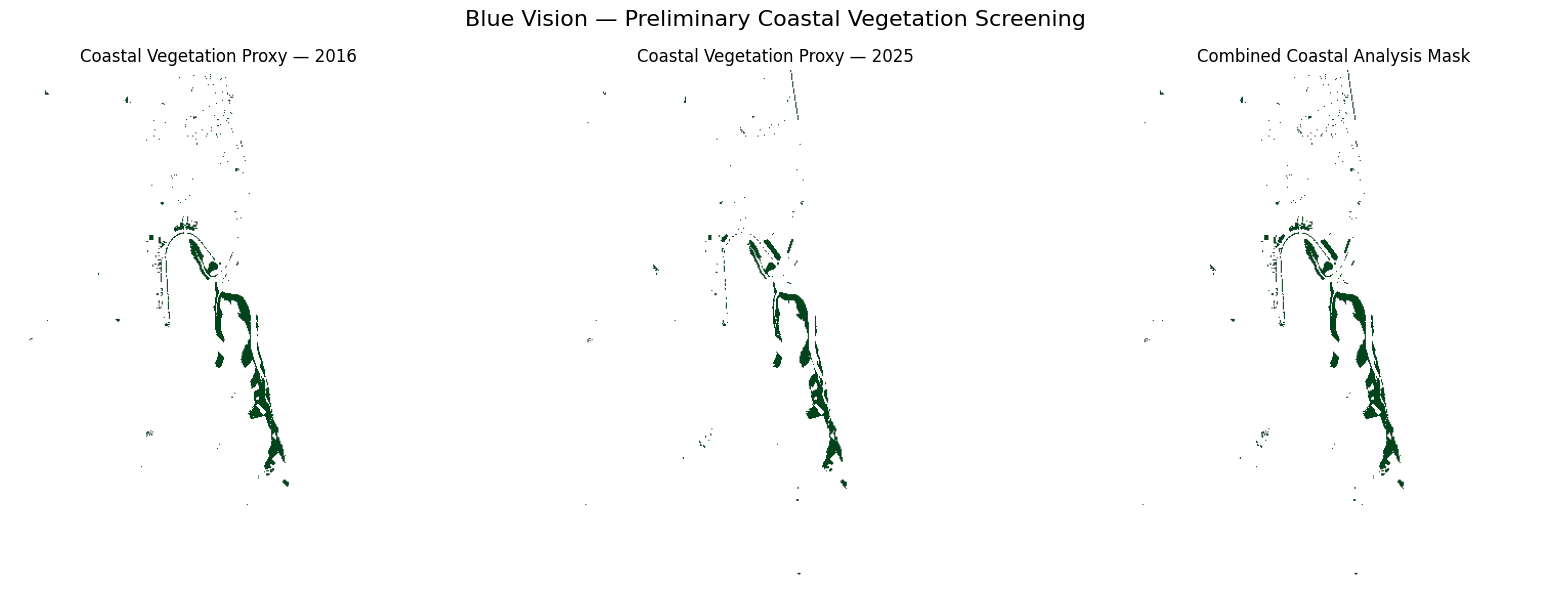

In [9]:
from scipy.ndimage import binary_dilation

def calculate_ndwi(composite):
    """Calculate the Normalized Difference Water Index."""
    green = composite.sel(band="B03")
    nir = composite.sel(band="B08")

    return (green - nir) / (green + nir)


# Calculate water indices
ndwi_2016 = calculate_ndwi(composite_2016)
ndwi_2025 = calculate_ndwi(composite_2025)

# Identify water pixels
water_2016 = np.isfinite(ndwi_2016.values) & (ndwi_2016.values > 0.0)
water_2025 = np.isfinite(ndwi_2025.values) & (ndwi_2025.values > 0.0)

# Create an approximately 200 m water-proximity zone
# Each pixel is 20 m; 10 dilation iterations are approximately 200 m
near_water_2016 = binary_dilation(water_2016, iterations=10)
near_water_2025 = binary_dilation(water_2025, iterations=10)

# Use the combined proximity zone for a consistent endpoint comparison
coastal_analysis_zone = near_water_2016 | near_water_2025

# Preliminary coastal vegetation screening masks
coastal_vegetation_2016 = (
    np.isfinite(ndvi_2016.values)
    & (ndvi_2016.values > 0.25)
    & coastal_analysis_zone
    & ~water_2016
)

coastal_vegetation_2025 = (
    np.isfinite(ndvi_2025.values)
    & (ndvi_2025.values > 0.25)
    & coastal_analysis_zone
    & ~water_2025
)

candidate_union = coastal_vegetation_2016 | coastal_vegetation_2025

# Display the screening results
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

axes[0].imshow(
    np.where(coastal_vegetation_2016, 1, np.nan),
    cmap="Greens",
    vmin=0,
    vmax=1
)
axes[0].set_title("Coastal Vegetation Proxy — 2016")
axes[0].axis("off")

axes[1].imshow(
    np.where(coastal_vegetation_2025, 1, np.nan),
    cmap="Greens",
    vmin=0,
    vmax=1
)
axes[1].set_title("Coastal Vegetation Proxy — 2025")
axes[1].axis("off")

axes[2].imshow(
    np.where(candidate_union, 1, np.nan),
    cmap="Greens",
    vmin=0,
    vmax=1
)
axes[2].set_title("Combined Coastal Analysis Mask")
axes[2].axis("off")

plt.suptitle(
    "Blue Vision — Preliminary Coastal Vegetation Screening",
    fontsize=16
)
plt.tight_layout()
plt.show()

## 7 — Remove Small Isolated Screening Patches

The preliminary masks capture coherent vegetation along the Kalba lagoon and coastal channels, but they also contain small isolated pixels that may represent urban landscaping, mixed pixels, or classification noise.

Connected patches smaller than five 20 m pixels (0.20 ha) are removed. This is a reproducible noise-reduction rule, not proof that all remaining vegetation is mangrove. The cleaned result remains a coastal vegetation proxy pending independent validation.

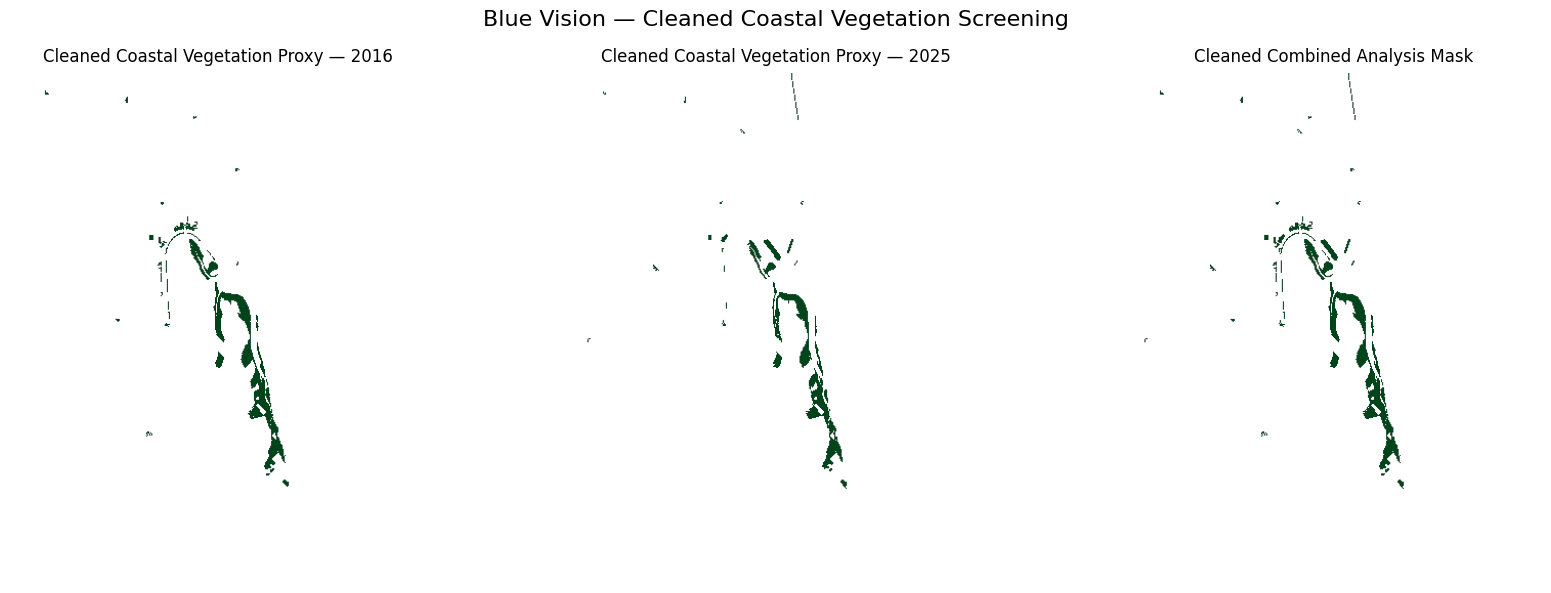

In [10]:
from scipy.ndimage import label

def remove_small_patches(mask, minimum_pixels=5):
    """Remove connected patches smaller than the selected pixel count."""

    structure = np.ones((3, 3), dtype=int)
    labelled_mask, number_of_patches = label(
        mask,
        structure=structure
    )

    patch_sizes = np.bincount(labelled_mask.ravel())
    keep_patch = patch_sizes >= minimum_pixels
    keep_patch[0] = False

    return keep_patch[labelled_mask]


# Remove isolated patches smaller than 0.20 ha
clean_vegetation_2016 = remove_small_patches(
    coastal_vegetation_2016,
    minimum_pixels=5
)

clean_vegetation_2025 = remove_small_patches(
    coastal_vegetation_2025,
    minimum_pixels=5
)

clean_candidate_union = (
    clean_vegetation_2016 | clean_vegetation_2025
)

# Display the cleaned screening masks
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

axes[0].imshow(
    np.where(clean_vegetation_2016, 1, np.nan),
    cmap="Greens",
    vmin=0,
    vmax=1
)
axes[0].set_title("Cleaned Coastal Vegetation Proxy — 2016")
axes[0].axis("off")

axes[1].imshow(
    np.where(clean_vegetation_2025, 1, np.nan),
    cmap="Greens",
    vmin=0,
    vmax=1
)
axes[1].set_title("Cleaned Coastal Vegetation Proxy — 2025")
axes[1].axis("off")

axes[2].imshow(
    np.where(clean_candidate_union, 1, np.nan),
    cmap="Greens",
    vmin=0,
    vmax=1
)
axes[2].set_title("Cleaned Combined Analysis Mask")
axes[2].axis("off")

plt.suptitle(
    "Blue Vision — Cleaned Coastal Vegetation Screening",
    fontsize=16
)
plt.tight_layout()
plt.show()

## 8 — Endpoint Area and Change Screening

The cleaned 2016 and 2025 masks are compared pixel by pixel. At 20 m spatial resolution, each pixel represents 400 m², or 0.04 hectares.

Four screening quantities are reported:

- Coastal vegetation proxy area in 2016
- Coastal vegetation proxy area in 2025
- Apparent loss: present in 2016 but absent in 2025
- Apparent gain: absent in 2016 but present in 2025

These statistics describe changes in the satellite-derived proxy only. They do not represent validated mangrove loss or restoration without independent reference data.

Coastal vegetation proxy area — 2016: 112.36 ha
Coastal vegetation proxy area — 2025: 97.24 ha
Persistent proxy vegetation: 84.92 ha
Apparent loss: 27.44 ha
Apparent gain: 12.32 ha
Net proxy change: -15.12 ha
Relative proxy change: -13.5%


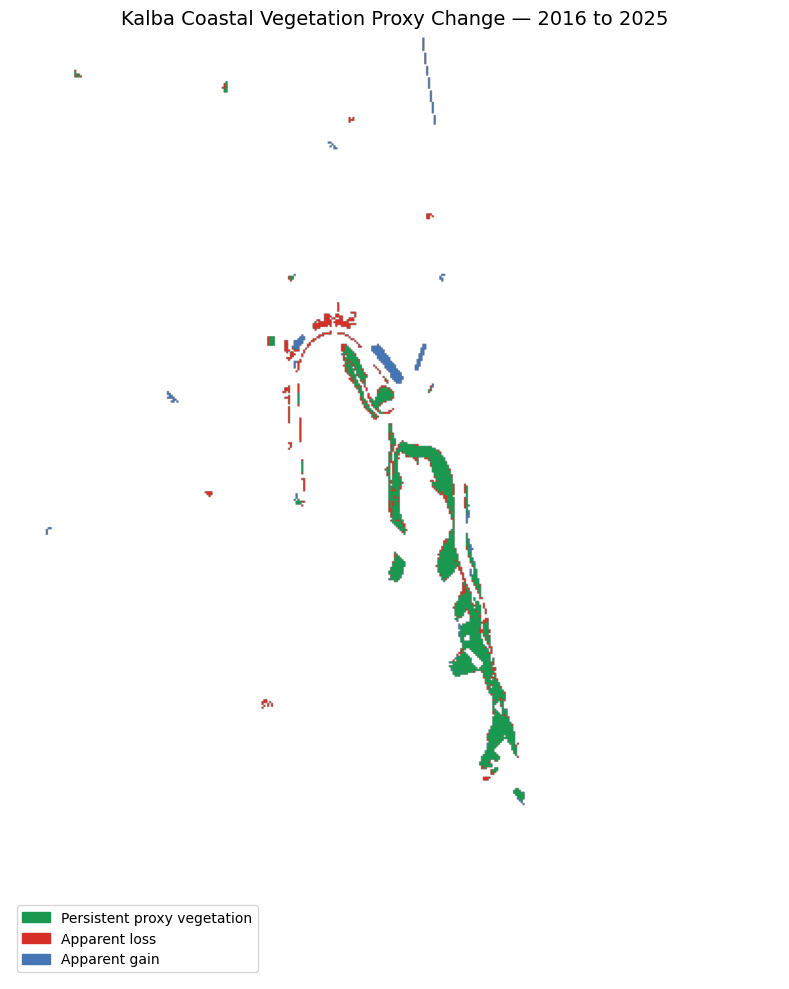

In [11]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Pixel area at 20 m resolution
PIXEL_AREA_HA = (20 * 20) / 10000

# Endpoint change classes
persistent_vegetation = (
    clean_vegetation_2016 & clean_vegetation_2025
)

apparent_loss = (
    clean_vegetation_2016 & ~clean_vegetation_2025
)

apparent_gain = (
    ~clean_vegetation_2016 & clean_vegetation_2025
)

# Calculate areas
area_2016_ha = clean_vegetation_2016.sum() * PIXEL_AREA_HA
area_2025_ha = clean_vegetation_2025.sum() * PIXEL_AREA_HA
persistent_ha = persistent_vegetation.sum() * PIXEL_AREA_HA
loss_ha = apparent_loss.sum() * PIXEL_AREA_HA
gain_ha = apparent_gain.sum() * PIXEL_AREA_HA
net_change_ha = area_2025_ha - area_2016_ha
percent_change = (net_change_ha / area_2016_ha) * 100

print(f"Coastal vegetation proxy area — 2016: {area_2016_ha:.2f} ha")
print(f"Coastal vegetation proxy area — 2025: {area_2025_ha:.2f} ha")
print(f"Persistent proxy vegetation: {persistent_ha:.2f} ha")
print(f"Apparent loss: {loss_ha:.2f} ha")
print(f"Apparent gain: {gain_ha:.2f} ha")
print(f"Net proxy change: {net_change_ha:.2f} ha")
print(f"Relative proxy change: {percent_change:.1f}%")

# Create categorical change map
change_classes = np.zeros_like(
    clean_vegetation_2016,
    dtype=np.uint8
)

change_classes[persistent_vegetation] = 1
change_classes[apparent_loss] = 2
change_classes[apparent_gain] = 3

masked_change = np.ma.masked_where(
    change_classes == 0,
    change_classes
)

change_cmap = ListedColormap([
    "#1a9850",
    "#d73027",
    "#4575b4"
])

change_norm = BoundaryNorm(
    [0.5, 1.5, 2.5, 3.5],
    change_cmap.N
)

plt.figure(figsize=(9, 10))
plt.imshow(
    masked_change,
    cmap=change_cmap,
    norm=change_norm
)
plt.title(
    "Kalba Coastal Vegetation Proxy Change — 2016 to 2025",
    fontsize=14
)
plt.axis("off")

legend_items = [
    Patch(color="#1a9850", label="Persistent proxy vegetation"),
    Patch(color="#d73027", label="Apparent loss"),
    Patch(color="#4575b4", label="Apparent gain")
]

plt.legend(
    handles=legend_items,
    loc="lower left",
    frameon=True
)
plt.tight_layout()
plt.show()

### 8.1 — Preliminary Endpoint Interpretation

The coastal vegetation proxy decreased from 112.36 ha in 2016 to 97.24 ha in 2025, representing a net proxy change of −15.12 ha (−13.5%).

Of the screened area, 84.92 ha remained persistent, 27.44 ha was classified as apparent loss, and 12.32 ha as apparent gain.

These values are screening results, not confirmed mangrove loss or gain. Much of the mapped change occurs along narrow lagoon and channel edges, where tidal variation and mixed land–water pixels can shift NDVI and NDWI classifications. Urban or non-mangrove vegetation may also remain in the mask.

The result should therefore be used to prioritise locations for closer assessment. Independent mangrove reference data, higher-resolution imagery, tide information, and field validation are required before reporting ecological loss.

## 9 — Ten-Year Coastal Vegetation Time Series

Endpoint comparison alone can exaggerate change if either year is unusual. Annual median composites are therefore generated for every year from 2016 to 2025 using the same seasonal window, spatial resolution, cloud mask, NDVI threshold, water-proximity rule, and minimum-patch filter.

The annual area series is used to determine whether the endpoint difference reflects a persistent trend or year-to-year variability. Because no independent mangrove labels are applied yet, all annual values remain coastal vegetation proxy estimates.

Processing 2017...


Processing 2018...


Processing 2019...


Processing 2020...


Processing 2021...


Processing 2022...


Processing 2023...


Processing 2024...


All annual composites created.
2016: 112.36 ha
2017: 104.52 ha
2018: 123.56 ha
2019: 126.64 ha
2020: 116.96 ha
2021: 119.88 ha
2022: 99.60 ha
2023: 107.64 ha
2024: 111.28 ha
2025: 97.24 ha
Linear trend: -1.49 ha/year
Trend R²: 0.209


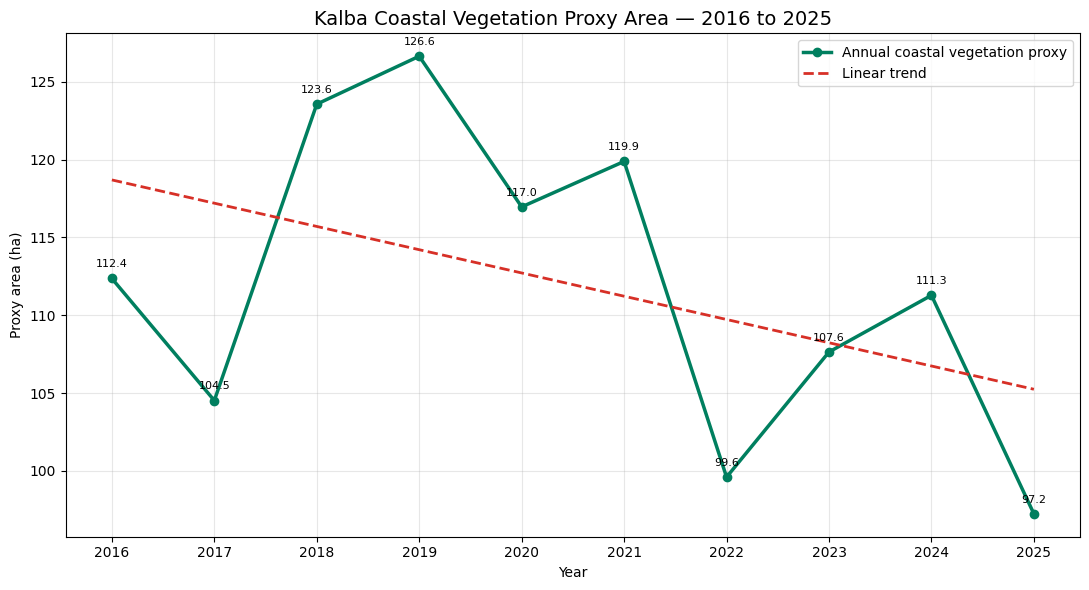

In [12]:
# Build and store annual composites
annual_composites = {
    2016: composite_2016,
    2025: composite_2025
}

for year in range(START_YEAR, END_YEAR + 1):
    if year not in annual_composites:
        print(f"Processing {year}...")
        annual_composites[year] = build_annual_composite(
            annual_items[year]
        )

print("All annual composites created.")

# Apply the same screening workflow to every year
annual_ndvi = {}
annual_proxy_masks = {}
annual_proxy_area_ha = {}

for year in range(START_YEAR, END_YEAR + 1):
    composite = annual_composites[year]

    ndvi = calculate_ndvi(composite)
    ndwi = calculate_ndwi(composite)

    water = (
        np.isfinite(ndwi.values)
        & (ndwi.values > 0.0)
    )

    vegetation_proxy = (
        np.isfinite(ndvi.values)
        & (ndvi.values > 0.25)
        & coastal_analysis_zone
        & ~water
    )

    cleaned_proxy = remove_small_patches(
        vegetation_proxy,
        minimum_pixels=5
    )

    annual_ndvi[year] = ndvi
    annual_proxy_masks[year] = cleaned_proxy
    annual_proxy_area_ha[year] = (
        cleaned_proxy.sum() * PIXEL_AREA_HA
    )

# Prepare the annual time series
years = np.array(sorted(annual_proxy_area_ha))
areas = np.array([
    annual_proxy_area_ha[year]
    for year in years
])

# Calculate a simple linear trend
trend_coefficients = np.polyfit(years, areas, 1)
trend_line = np.polyval(trend_coefficients, years)

residual_sum = np.sum((areas - trend_line) ** 2)
total_sum = np.sum((areas - areas.mean()) ** 2)
trend_r_squared = 1 - (residual_sum / total_sum)

# Print annual estimates
for year in years:
    print(
        f"{year}: "
        f"{annual_proxy_area_ha[year]:.2f} ha"
    )

print(
    f"Linear trend: "
    f"{trend_coefficients[0]:.2f} ha/year"
)
print(
    f"Trend R²: "
    f"{trend_r_squared:.3f}"
)

# Plot the time series
plt.figure(figsize=(11, 6))

plt.plot(
    years,
    areas,
    marker="o",
    linewidth=2.5,
    color="#007f5f",
    label="Annual coastal vegetation proxy"
)

plt.plot(
    years,
    trend_line,
    linestyle="--",
    linewidth=2,
    color="#d73027",
    label="Linear trend"
)

for year, area in zip(years, areas):
    plt.annotate(
        f"{area:.1f}",
        (year, area),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.title(
    "Kalba Coastal Vegetation Proxy Area — 2016 to 2025",
    fontsize=14
)
plt.xlabel("Year")
plt.ylabel("Proxy area (ha)")
plt.xticks(years)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import linregress, t

trend_test = linregress(years, areas)

degrees_of_freedom = len(years) - 2
critical_t = t.ppf(
    0.975,
    degrees_of_freedom
)

confidence_lower = (
    trend_test.slope
    - critical_t * trend_test.stderr
)

confidence_upper = (
    trend_test.slope
    + critical_t * trend_test.stderr
)

print(f"Slope: {trend_test.slope:.2f} ha/year")
print(f"R²: {trend_test.rvalue ** 2:.3f}")
print(f"p-value: {trend_test.pvalue:.3f}")
print(
    "95% confidence interval: "
    f"{confidence_lower:.2f} to "
    f"{confidence_upper:.2f} ha/year"
)

if trend_test.pvalue < 0.05:
    print("The linear trend is statistically significant at α = 0.05.")
else:
    print("The linear trend is not statistically significant at α = 0.05.")

Slope: -1.49 ha/year
R²: 0.209
p-value: 0.184
95% confidence interval: -3.87 to 0.88 ha/year
The linear trend is not statistically significant at α = 0.05.


### 9.1 — Time-Series Interpretation

The annual coastal vegetation proxy varied between 97.24 ha and 126.64 ha from 2016 to 2025. A simple linear regression produced an estimated slope of −1.49 ha/year.

However, the trend was not statistically significant at α = 0.05 (p = 0.184), and the 95% confidence interval ranged from −3.87 to +0.88 ha/year. The low R² value of 0.209 also indicates that a linear trend explains only 20.9% of the observed annual variation.

Therefore, this Proof of Concept identifies a possible declining signal that warrants closer investigation, but it does not provide sufficient evidence to conclude that Kalba mangrove extent experienced a persistent linear decline. Interannual variability, tidal conditions, mixed pixels, threshold sensitivity, and non-mangrove coastal vegetation may influence the estimates.

## 10 — NDVI Threshold Sensitivity Analysis

The coastal vegetation proxy depends partly on the selected NDVI threshold. To test the robustness of the result, the complete ten-year workflow is repeated using three plausible thresholds: 0.20, 0.25, and 0.30.

For each threshold, the analysis reports the 2016 and 2025 proxy areas, endpoint change, linear trend, R², and p-value.

This sensitivity test does not replace validation against independent mangrove reference data. It shows whether the main conclusion is stable or highly dependent on one manually selected threshold.

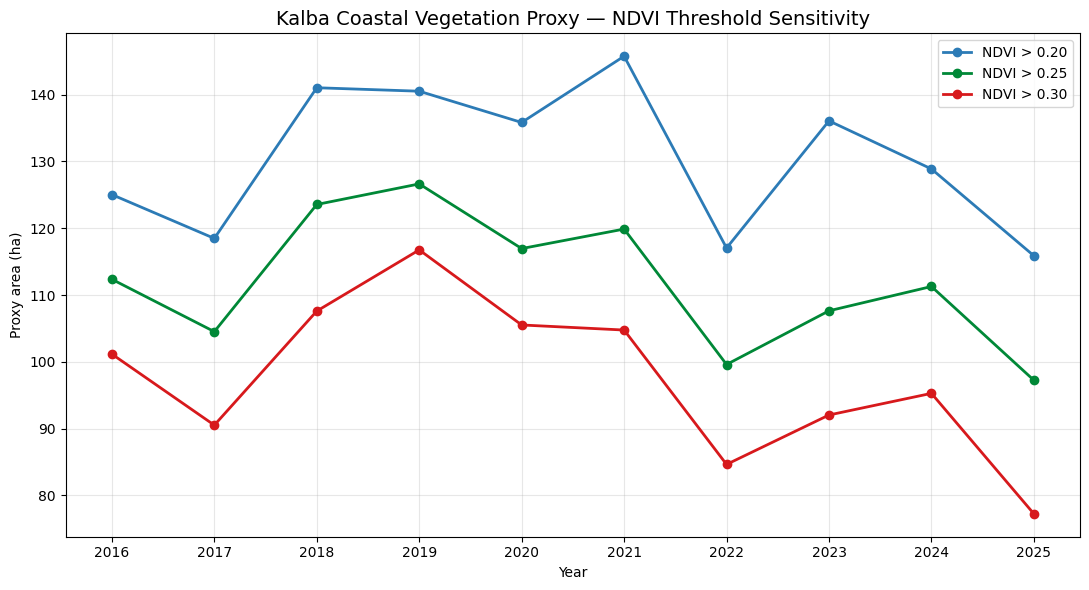

In [14]:
import pandas as pd

ndvi_thresholds = [0.20, 0.25, 0.30]
sensitivity_rows = []
sensitivity_series = {}

for threshold in ndvi_thresholds:
    threshold_areas = []

    for year in years:
        ndvi = annual_ndvi[year]
        ndwi = calculate_ndwi(
            annual_composites[year]
        )

        water = (
            np.isfinite(ndwi.values)
            & (ndwi.values > 0.0)
        )

        vegetation_proxy = (
            np.isfinite(ndvi.values)
            & (ndvi.values > threshold)
            & coastal_analysis_zone
            & ~water
        )

        cleaned_proxy = remove_small_patches(
            vegetation_proxy,
            minimum_pixels=5
        )

        threshold_areas.append(
            cleaned_proxy.sum() * PIXEL_AREA_HA
        )

    threshold_areas = np.array(threshold_areas)
    sensitivity_series[threshold] = threshold_areas

    regression = linregress(
        years,
        threshold_areas
    )

    area_2016 = threshold_areas[0]
    area_2025 = threshold_areas[-1]
    endpoint_change = area_2025 - area_2016
    endpoint_percent = (
        endpoint_change / area_2016
    ) * 100

    sensitivity_rows.append({
        "NDVI threshold": threshold,
        "2016 area (ha)": area_2016,
        "2025 area (ha)": area_2025,
        "Endpoint change (ha)": endpoint_change,
        "Endpoint change (%)": endpoint_percent,
        "Slope (ha/year)": regression.slope,
        "R²": regression.rvalue ** 2,
        "p-value": regression.pvalue
    })

sensitivity_results = pd.DataFrame(
    sensitivity_rows
).round(3)

display(sensitivity_results)

# Plot threshold sensitivity
plt.figure(figsize=(11, 6))

threshold_colours = {
    0.20: "#2c7bb6",
    0.25: "#008837",
    0.30: "#d7191c"
}

for threshold in ndvi_thresholds:
    plt.plot(
        years,
        sensitivity_series[threshold],
        marker="o",
        linewidth=2,
        color=threshold_colours[threshold],
        label=f"NDVI > {threshold:.2f}"
    )

plt.title(
    "Kalba Coastal Vegetation Proxy — NDVI Threshold Sensitivity",
    fontsize=14
)
plt.xlabel("Year")
plt.ylabel("Proxy area (ha)")
plt.xticks(years)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 10.1 — Sensitivity Interpretation

All three NDVI thresholds produced a lower coastal vegetation proxy area in 2025 than in 2016. This indicates that the direction of the endpoint signal is consistent across the tested thresholds.

However, the estimated magnitude was sensitive to the selected threshold. Endpoint change ranged from −9.16 ha (−7.3%) at NDVI > 0.20 to −23.92 ha (−23.6%) at NDVI > 0.30.

None of the ten-year linear trends was statistically significant at α = 0.05:

- NDVI > 0.20: p = 0.660
- NDVI > 0.25: p = 0.184
- NDVI > 0.30: p = 0.097

The sensitivity analysis therefore supports a consistent declining screening signal, but not a validated estimate of mangrove loss. The magnitude depends strongly on the vegetation threshold, reinforcing the need for independent mangrove labels, tide information, and higher-resolution validation.

## 11 — Data Source, Licence, and Reproducibility

### Satellite data

- Dataset: Sentinel-2 Level-2A surface reflectance
- Provider: European Union Copernicus Programme
- Access service: Microsoft Planetary Computer STAC API
- Collection: `sentinel-2-l2a`
- Study period: 2016–2025
- Working resolution: 20 m
- Seasonal window: February–April
- Maximum selected observations: six per year
- Scene-level cloud-cover filter: less than 20%
- Independent reference: ESA WorldCover 2021 mangrove class
- Hyperspectral demonstration: EnMAP Level-2A scene acquired on 11 September 2025

### Attribution

Contains modified Copernicus Sentinel data (2016–2025), accessed through the Microsoft Planetary Computer.

Contains modified ESA WorldCover 2021 data.

Contains modified EnMAP data ©DLR 2025.

### Reproducibility

The core Sentinel-2 and ESA WorldCover workflow uses openly accessible satellite data and open-source Python packages. The Area of Interest, date range, spectral bands, cloud-screening method, index formulas, thresholds, spatial resolution, and patch-removal rule are documented in this notebook.

The EnMAP demonstration requires separately downloaded Level-2A spectral-image and quality-mask files. These files are optionally uploaded to the temporary Colab session and are not included in the public repository. To reproduce the hyperspectral section, users must obtain the same scene from the official DLR EnMAP portal under the applicable access and licence conditions.

No account credentials, passwords, access tokens, or personal files are stored in this notebook.

## 12 — Validation Status and Limitations

### Validation completed in this Proof of Concept

- Visual inspection confirmed spatial alignment between the 2016 and 2025 composites.
- Sentinel-2 SCL quality flags were used to remove cloud, cirrus, shadow, snow/ice, saturated, and no-data pixels.
- Ten annual composites were analysed instead of relying only on two individual scenes.
- The linear trend was tested statistically: slope = −1.49 ha/year, R² = 0.209, and p = 0.184.
- NDVI threshold sensitivity was tested at 0.20, 0.25, and 0.30.
- None of the tested ten-year trends was statistically significant at α = 0.05.
- The 2021 proxy was compared with the ESA WorldCover 2021 mangrove class.
- Reference-map agreement produced precision = 0.720, recall = 0.822, F1-score = 0.768, and IoU = 0.623.

### Validation not yet completed

This notebook does not include field-based mangrove ground-truth labels. Therefore, the reported precision, recall, F1-score, and IoU represent agreement with the ESA WorldCover satellite-derived reference map, not final field-validated classification accuracy.

### Required next validation

The coastal vegetation proxy should be evaluated further using independent evidence such as:

- An official Kalba mangrove or protected-area boundary
- Global Mangrove Watch reference data
- High-resolution permitted imagery interpreted by a domain expert
- Spatially independent field observations

Reference samples should be spatially separated from any samples used to tune the classification thresholds. Field-based validation should then be used to calculate a final confusion matrix and classification metrics.

### Main limitations

- NDVI and NDWI are screening indicators, not direct ecological measurements.
- Tide level and acquisition geometry may affect narrow shoreline pixels.
- The 20 m working resolution creates mixed vegetation–water pixels.
- The mask may include non-mangrove coastal or urban vegetation.
- Results are sensitive to the NDVI threshold.
- ESA WorldCover is a satellite-derived reference rather than field ground truth.
- Carbon stock is not estimated because validated mangrove extent and a justified carbon-density coefficient are not yet available.

In [15]:
# Independent reference check using ESA WorldCover 2021

import numpy as np
import stackstac
import planetary_computer

from pystac_client import Client
from rasterio.enums import Resampling

# Kalba Area of Interest: west, south, east, north
KALBA_BBOX = [56.32, 24.96, 56.40, 25.05]

# Open the Microsoft Planetary Computer catalogue
worldcover_catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

# Search for ESA WorldCover 2021 over Kalba
worldcover_search = worldcover_catalog.search(
    collections=["esa-worldcover"],
    bbox=KALBA_BBOX,
    datetime="2021-01-01/2021-12-31"
)

worldcover_items = list(worldcover_search.items())

print("WorldCover items found:", len(worldcover_items))

if len(worldcover_items) == 0:
    raise ValueError("No ESA WorldCover 2021 item was found over the Kalba AOI.")

# Load the WorldCover map and align it to the existing 20 m analysis grid
worldcover = stackstac.stack(
    worldcover_items,
    assets=["map"],
    bounds_latlon=KALBA_BBOX,
    epsg=32640,
    resolution=20,
    dtype="float64",
    fill_value=np.nan,
    rescale=False,
    resampling=Resampling.nearest
).isel(time=0, band=0).compute()

# ESA WorldCover class 95 represents mangroves
worldcover_mangrove = worldcover.values == 95

# Use the Blue Vision coastal vegetation proxy for the same year
proxy_2021 = annual_proxy_masks[2021]

# Confirm that both masks have the same dimensions
print("Blue Vision mask shape:", proxy_2021.shape)
print("WorldCover mask shape:", worldcover_mangrove.shape)

if proxy_2021.shape != worldcover_mangrove.shape:
    raise ValueError(
        "The Blue Vision and WorldCover masks do not have matching dimensions."
    )

# Calculate spatial agreement
intersection = proxy_2021 & worldcover_mangrove
union = proxy_2021 | worldcover_mangrove

proxy_pixels = int(proxy_2021.sum())
reference_pixels = int(worldcover_mangrove.sum())
intersection_pixels = int(intersection.sum())
union_pixels = int(union.sum())

precision = (
    intersection_pixels / proxy_pixels
    if proxy_pixels > 0 else np.nan
)

recall = (
    intersection_pixels / reference_pixels
    if reference_pixels > 0 else np.nan
)

f1 = (
    2 * precision * recall / (precision + recall)
    if np.isfinite(precision)
    and np.isfinite(recall)
    and (precision + recall) > 0
    else np.nan
)

iou = (
    intersection_pixels / union_pixels
    if union_pixels > 0 else np.nan
)

print(f"Blue Vision proxy area — 2021: {proxy_pixels * PIXEL_AREA_HA:.2f} ha")
print(f"WorldCover mangrove area — 2021: {reference_pixels * PIXEL_AREA_HA:.2f} ha")
print(f"Overlap area: {intersection_pixels * PIXEL_AREA_HA:.2f} ha")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"IoU: {iou:.3f}")

WorldCover items found: 1
Blue Vision mask shape: (501, 407)
WorldCover mask shape: (501, 407)
Blue Vision proxy area — 2021: 119.88 ha
WorldCover mangrove area — 2021: 105.00 ha
Overlap area: 86.36 ha
Precision: 0.720
Recall: 0.822
F1-score: 0.768
IoU: 0.623


### 12.1 — Independent Reference Comparison

The 2021 Blue Vision coastal vegetation proxy was compared with the ESA WorldCover 2021 mangrove class after alignment to the same 20 m analysis grid.

The proxy covered 119.88 ha, while the WorldCover mangrove reference covered 105.00 ha. Their spatial overlap was 86.36 ha. The comparison produced a precision of 0.720, recall of 0.822, F1-score of 0.768, and Intersection over Union (IoU) of 0.623.

These results provide encouraging evidence that the screening proxy captures a substantial proportion of independently mapped mangrove areas. However, ESA WorldCover is a satellite-derived land-cover product rather than field ground truth. The metrics should therefore be interpreted as reference-map agreement, not final ecological classification accuracy.

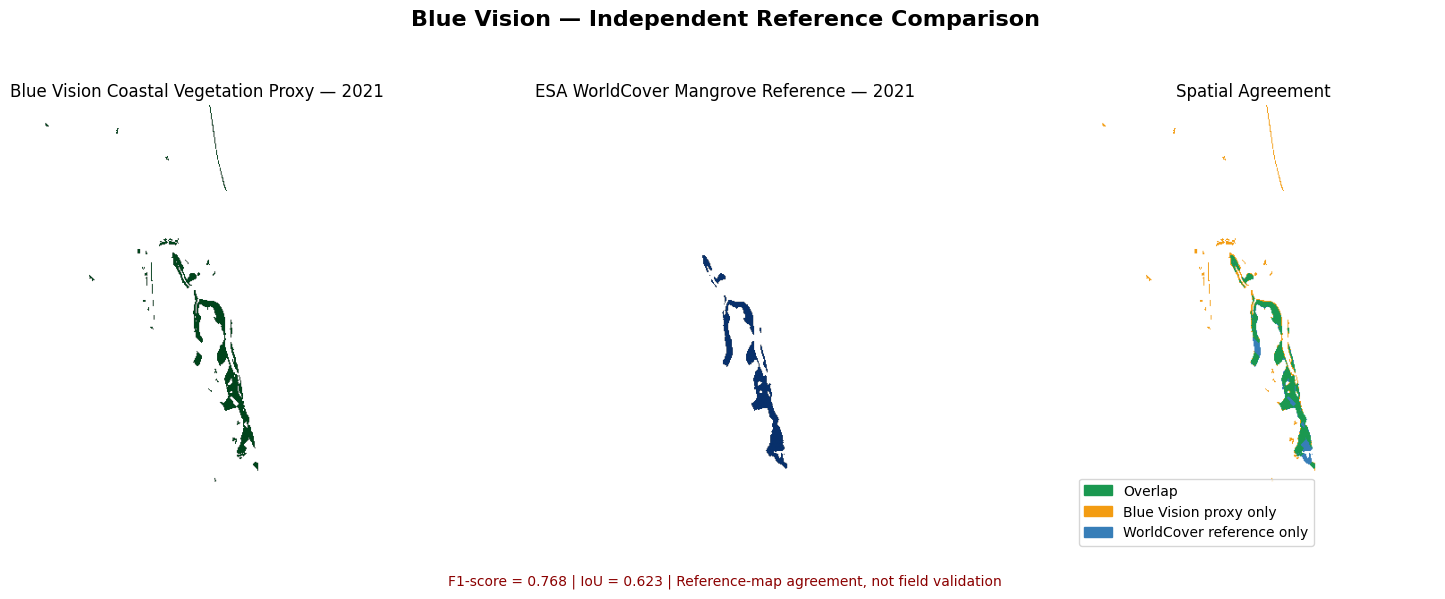

Validation figure saved as: Blue_Vision_WorldCover_Validation.png


In [16]:
# Visualise the independent reference comparison

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

agreement_map = np.zeros(proxy_2021.shape, dtype=np.uint8)

# 1 = Blue Vision proxy only
agreement_map[proxy_2021 & ~worldcover_mangrove] = 1

# 2 = WorldCover reference only
agreement_map[~proxy_2021 & worldcover_mangrove] = 2

# 3 = Spatial overlap
agreement_map[proxy_2021 & worldcover_mangrove] = 3

agreement_cmap = ListedColormap([
    "white",
    "#f39c12",
    "#377eb8",
    "#1a9850"
])

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(
    np.where(proxy_2021, 1, np.nan),
    cmap="Greens",
    vmin=0,
    vmax=1
)
axes[0].set_title("Blue Vision Coastal Vegetation Proxy — 2021")
axes[0].axis("off")

axes[1].imshow(
    np.where(worldcover_mangrove, 1, np.nan),
    cmap="Blues",
    vmin=0,
    vmax=1
)
axes[1].set_title("ESA WorldCover Mangrove Reference — 2021")
axes[1].axis("off")

axes[2].imshow(
    agreement_map,
    cmap=agreement_cmap,
    vmin=0,
    vmax=3
)
axes[2].set_title("Spatial Agreement")
axes[2].axis("off")

legend_items = [
    Patch(color="#1a9850", label="Overlap"),
    Patch(color="#f39c12", label="Blue Vision proxy only"),
    Patch(color="#377eb8", label="WorldCover reference only")
]

axes[2].legend(
    handles=legend_items,
    loc="lower left",
    frameon=True
)

fig.suptitle(
    "Blue Vision — Independent Reference Comparison",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.5,
    0.02,
    "F1-score = 0.768 | IoU = 0.623 | Reference-map agreement, not field validation",
    ha="center",
    color="darkred"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])

plt.savefig(
    str(RESULTS_DIR / "Blue_Vision_WorldCover_Validation.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Validation figure saved as: Blue_Vision_WorldCover_Validation.png")

## 13 — Product Concept and End-User Delivery

### Problem and users

Environmental authorities and reserve managers need a repeatable way to screen large coastal areas and identify locations that may require field inspection. Without this workflow, staff must compare imagery manually or depend on infrequent surveys.

### Decision supported

Blue Vision does not automatically declare mangrove loss. It highlights coastal locations showing persistent or unusual vegetation change so managers can prioritise:

- Field inspections
- Restoration monitoring
- Conservation planning
- Requests for higher-resolution imagery
- Investigation of possible coastal disturbance

### Proposed delivery

The operational product would provide:

- An interactive web dashboard
- Annual coastal vegetation and NDVI maps
- A ten-year trend chart
- Location-based change alerts
- Downloadable maps and summary reports
- A REST API for integration with environmental monitoring systems

### Alert logic

An alert would be generated only when a decline:

1. Persists across multiple observations,
2. Exceeds an agreed area or NDVI threshold,
3. Passes cloud and quality screening, and
4. Is reviewed against tide information and higher-resolution reference data.

The current notebook is the analytical Proof of Concept underlying that future product.

## 13.1 — Proof-of-Concept Summary Dashboard

The following six-panel dashboard combines the most decision-relevant outputs: recent true colour, endpoint NDVI, the cleaned 2025 coastal vegetation proxy, endpoint change classes, and the ten-year area series.

The dashboard is designed as a screening product for environmental managers. All mapped areas remain provisional until independent mangrove validation is completed.

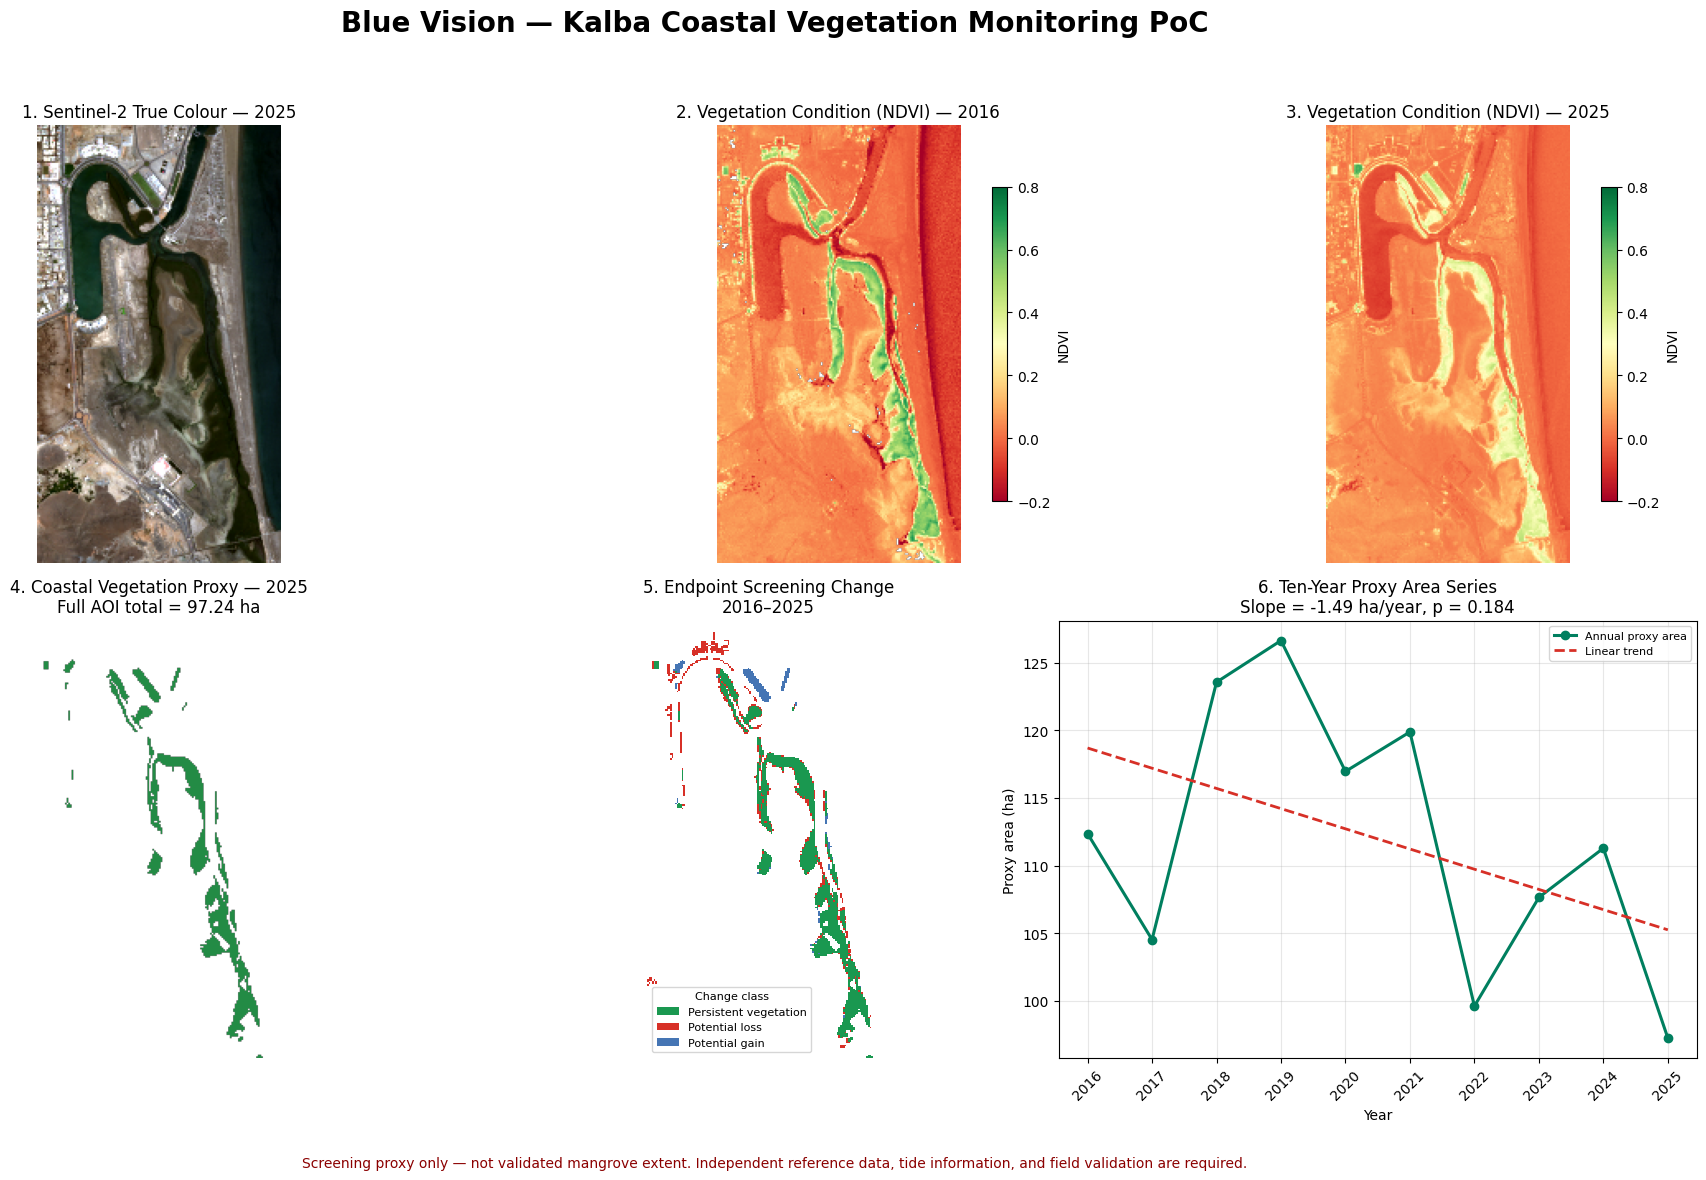

Corrected dashboard saved as: Blue_Vision_Kalba_PoC_Dashboard.png


In [17]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from scipy.ndimage import label
import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------------
# 1. Identify the largest coherent coastal vegetation patches
# ---------------------------------------------------------

labelled_union, number_of_union_patches = label(
    clean_candidate_union,
    structure=np.ones((3, 3), dtype=int)
)

union_patch_sizes = np.bincount(
    labelled_union.ravel()
)

valid_labels = np.arange(
    1,
    len(union_patch_sizes)
)

# Select up to eight of the largest non-background patches
number_of_focus_patches = min(
    8,
    len(valid_labels)
)

largest_labels = valid_labels[
    np.argsort(union_patch_sizes[1:])[-number_of_focus_patches:]
]

focus_core = np.isin(
    labelled_union,
    largest_labels
)


# ---------------------------------------------------------
# 2. Automatically crop around the selected patches
# ---------------------------------------------------------

focus_rows, focus_columns = np.where(
    focus_core
)

if len(focus_rows) == 0:
    raise ValueError(
        "No coastal vegetation patches were found for the dashboard."
    )

padding_pixels = 12

row_start = max(
    focus_rows.min() - padding_pixels,
    0
)

row_end = min(
    focus_rows.max() + padding_pixels + 1,
    clean_candidate_union.shape[0]
)

column_start = max(
    focus_columns.min() - padding_pixels,
    0
)

column_end = min(
    focus_columns.max() + padding_pixels + 1,
    clean_candidate_union.shape[1]
)

focus_slice = (
    slice(row_start, row_end),
    slice(column_start, column_end)
)


# ---------------------------------------------------------
# 3. Prepare the cropped spatial products
# ---------------------------------------------------------

focus_rgb_2025 = rgb_2025[
    row_start:row_end,
    column_start:column_end,
    :
]

focus_ndvi_2016 = ndvi_2016.values[
    focus_slice
]

focus_ndvi_2025 = ndvi_2025.values[
    focus_slice
]

focus_proxy_2025 = np.where(
    clean_vegetation_2025[focus_slice],
    1,
    np.nan
)

focus_change_classes = change_classes[
    focus_slice
]

focus_masked_change = np.ma.masked_where(
    focus_change_classes == 0,
    focus_change_classes
)


# ---------------------------------------------------------
# 4. Create a dedicated endpoint-change colour scheme
#
# Expected change-class values:
# 0 = background
# 1 = persistent vegetation
# 2 = potential loss
# 3 = potential gain
# ---------------------------------------------------------

dashboard_change_cmap = ListedColormap([
    "#1a9850",  # Persistent vegetation
    "#d73027",  # Potential loss
    "#4575b4"   # Potential gain
])

dashboard_change_norm = BoundaryNorm(
    [0.5, 1.5, 2.5, 3.5],
    dashboard_change_cmap.N
)

endpoint_change_legend = [
    Patch(
        facecolor="#1a9850",
        edgecolor="none",
        label="Persistent vegetation"
    ),
    Patch(
        facecolor="#d73027",
        edgecolor="none",
        label="Potential loss"
    ),
    Patch(
        facecolor="#4575b4",
        edgecolor="none",
        label="Potential gain"
    )
]


# ---------------------------------------------------------
# 5. Create the six-panel dashboard
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(19, 12)
)


# Panel 1: focused 2025 true colour

axes[0, 0].imshow(
    focus_rgb_2025
)

axes[0, 0].set_title(
    "1. Sentinel-2 True Colour — 2025"
)

axes[0, 0].axis("off")


# Panel 2: focused 2016 NDVI

panel_ndvi_2016 = axes[0, 1].imshow(
    focus_ndvi_2016,
    cmap="RdYlGn",
    vmin=-0.2,
    vmax=0.8
)

axes[0, 1].set_title(
    "2. Vegetation Condition (NDVI) — 2016"
)

axes[0, 1].axis("off")

fig.colorbar(
    panel_ndvi_2016,
    ax=axes[0, 1],
    shrink=0.72,
    label="NDVI"
)


# Panel 3: focused 2025 NDVI

panel_ndvi_2025 = axes[0, 2].imshow(
    focus_ndvi_2025,
    cmap="RdYlGn",
    vmin=-0.2,
    vmax=0.8
)

axes[0, 2].set_title(
    "3. Vegetation Condition (NDVI) — 2025"
)

axes[0, 2].axis("off")

fig.colorbar(
    panel_ndvi_2025,
    ax=axes[0, 2],
    shrink=0.72,
    label="NDVI"
)


# Panel 4: focused cleaned 2025 proxy

axes[1, 0].imshow(
    focus_proxy_2025,
    cmap=ListedColormap(["#238b45"]),
    vmin=0,
    vmax=1
)

axes[1, 0].set_title(
    "4. Coastal Vegetation Proxy — 2025\n"
    f"Full AOI total = {area_2025_ha:.2f} ha"
)

axes[1, 0].axis("off")


# Panel 5: endpoint vegetation change

axes[1, 1].imshow(
    focus_masked_change,
    cmap=dashboard_change_cmap,
    norm=dashboard_change_norm,
    interpolation="nearest"
)

axes[1, 1].set_title(
    "5. Endpoint Screening Change\n"
    "2016–2025"
)

axes[1, 1].axis("off")

axes[1, 1].legend(
    handles=endpoint_change_legend,
    loc="lower left",
    fontsize=8,
    frameon=True,
    title="Change class",
    title_fontsize=8
)


# Panel 6: ten-year proxy area series

axes[1, 2].plot(
    years,
    areas,
    marker="o",
    linewidth=2.2,
    color="#007f5f",
    label="Annual proxy area"
)

axes[1, 2].plot(
    years,
    trend_line,
    linestyle="--",
    linewidth=2,
    color="#d73027",
    label="Linear trend"
)

axes[1, 2].set_title(
    "6. Ten-Year Proxy Area Series\n"
    f"Slope = {trend_test.slope:.2f} ha/year, "
    f"p = {trend_test.pvalue:.3f}"
)

axes[1, 2].set_xlabel(
    "Year"
)

axes[1, 2].set_ylabel(
    "Proxy area (ha)"
)

axes[1, 2].set_xticks(
    years
)

axes[1, 2].tick_params(
    axis="x",
    rotation=45
)

axes[1, 2].grid(
    alpha=0.3
)

axes[1, 2].legend(
    fontsize=8
)


# ---------------------------------------------------------
# 6. Dashboard title and scientific caution
# ---------------------------------------------------------

fig.suptitle(
    "Blue Vision — Kalba Coastal Vegetation Monitoring PoC",
    fontsize=20,
    fontweight="bold"
)

fig.text(
    0.5,
    0.015,
    "Screening proxy only — not validated mangrove extent. "
    "Independent reference data, tide information, and field validation are required.",
    ha="center",
    fontsize=10,
    color="#8b0000"
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.95]
)


# ---------------------------------------------------------
# 7. Save and display the corrected dashboard
# ---------------------------------------------------------

dashboard_filename = RESULTS_DIR / (
    "Blue_Vision_Kalba_PoC_Dashboard.png"
)

plt.savefig(
    dashboard_filename,
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(
    f"Corrected dashboard saved as: {dashboard_filename}"
)

## 13.2 — EnMAP Hyperspectral Demonstration and Satellite 813 Transferability

A real EnMAP Level-2A hyperspectral scene acquired over Kalba on 11 September 2025 was integrated into the Proof of Concept. The scene contains 224 spectral bands from approximately 0.418 to 2.445 µm at 30 m spatial resolution.

Cloud masking retained 84.4% clear pixels within the Kalba Area of Interest. Five wavelengths were selected from the hyperspectral cube for targeted vegetation diagnosis:

- Green: 0.5611 µm
- Red: 0.6666 µm
- Red edge: 0.7066 µm
- Near infrared: 0.8012 µm
- Shortwave infrared water-sensitive band: 1.2350 µm

The EnMAP scene was used to calculate NDVI, a narrow-band red-edge index (NDRE), and a vegetation water-content index. The analysis was then restricted to the 2025 Sentinel-2 coastal vegetation screening proxy.

Within 900 valid coastal vegetation pixels, median NDRE was 0.206 and the 10th–90th percentile range was 0.166–0.258. The median water-content index was −0.006, with a 10th–90th percentile range of −0.051–0.037.

A relative follow-up screen flagged 177 pixels in the lowest 10% of at least one hyperspectral indicator. Only three pixels, approximately 0.27 ha, were within the lowest 10% of both indicators. These locations are prioritisation candidates for closer imagery review or field inspection, not confirmed vegetation stress.

This demonstrates the value of combining:

- Sentinel-2 for frequent and long-term monitoring
- EnMAP for detailed spectral diagnosis
- Independent reference maps and field observations for validation

The same modular workflow can be transferred to Satellite 813 when suitable imagery becomes available. Sensor-specific wavelengths, calibration, atmospheric correction, and quality masks must be checked before transfer.

### Hyperspectral Limitations

- The EnMAP assessment uses one acquisition date and does not establish a hyperspectral trend.
- The September 2025 acquisition is not seasonally identical to the February–April Sentinel-2 composites.
- The percentile thresholds are relative screening rules, not universal ecological stress thresholds.
- Field measurements are required before interpreting the flagged locations as degraded mangrove.
- The original licensed EnMAP image will not be distributed through the public repository.

Contains modified EnMAP data ©DLR 2025.



In [18]:
# Search the official DLR EnMAP catalogue for scenes over Kalba

from pystac_client import Client

ENMAP_STAC_URL = "https://geoservice.dlr.de/eoc/ogc/stac/v1"

enmap_catalog = Client.open(ENMAP_STAC_URL)

enmap_search = enmap_catalog.search(
    collections=["ENMAP_HSI_L2A"],
    bbox=KALBA_BBOX
)

enmap_items = list(enmap_search.items())

print(f"EnMAP L2A scenes found over Kalba: {len(enmap_items)}")

if enmap_items:
    for item in enmap_items:
        acquisition_date = (
            item.datetime.strftime("%Y-%m-%d")
            if item.datetime is not None
            else "Unknown date"
        )
        print(f"- {acquisition_date} | {item.id}")
else:
    print("No open EnMAP L2A scene currently covers the Kalba AOI.")

EnMAP L2A scenes found over Kalba: 1
- 2025-09-11 | ENMAP01-____L2A-DT0000152124_20250911T072327Z_006_V010502_20250914T181224Z


In [19]:
# Inspect the available EnMAP scene before downloading data

enmap_item = enmap_items[0]

print("Scene ID:", enmap_item.id)
print("Acquisition date:", enmap_item.datetime)
print("Bounding box:", enmap_item.bbox)
print("Cloud cover:", enmap_item.properties.get("eo:cloud_cover", "Not reported"))

print("\nAvailable assets:")
for asset_name, asset in enmap_item.assets.items():
    print(
        f"- {asset_name} | "
        f"title: {asset.title} | "
        f"roles: {asset.roles}"
    )

Scene ID: ENMAP01-____L2A-DT0000152124_20250911T072327Z_006_V010502_20250914T181224Z
Acquisition date: 2025-09-11 07:23:29.497054+00:00
Bounding box: [56.1129165, 24.7915166, 56.4848107, 25.108517]
Cloud cover: 19

Available assets:
- metadata | title: Metadata | roles: ['metadata']
- image | title: Spectral Image | roles: ['data']
- vnir | title: Quicklook VNIR | roles: ['overview', 'visual']
- thumbnail | title: Thumbnail VNIR | roles: ['thumbnail']
- swir | title: Quicklook SWIR | roles: ['overview']
- quality_classes | title: Quality classes | roles: ['quality']
- quality_cloud | title: Quality cloud | roles: ['quality', 'cloud']
- quality_cloud_shadow | title: Quality cloud shadow | roles: ['quality', 'cloud-shadow']
- quality_haze | title: Quality haze | roles: ['quality', 'haze']
- quality_cirrus | title: Quality cirrus | roles: ['quality', 'cirrus']
- quality_snow | title: Quality snow | roles: ['quality', 'snow']
- quality_testflags | title: Quality test flags | roles: ['quali

### Optional EnMAP input files

To recompute the EnMAP section, download the identified scene from the official DLR EnMAP portal and upload the following three licensed files into `data/enmap_optional/` in the Colab session:

- `*SPECTRAL_IMAGE_COG.tiff`
- `*QL_QUALITY_CLOUD_COG.tiff`
- `*QL_QUALITY_CLASSES_COG.tiff`

The original rasters are not redistributed in this repository.


In [30]:
from pathlib import Path
import glob

ENMAP_DATA_DIR = PROJECT_ROOT / "data" / "enmap_optional"

spectral_matches = sorted(ENMAP_DATA_DIR.glob("*SPECTRAL_IMAGE_COG.*"))
cloud_matches = sorted(ENMAP_DATA_DIR.glob("*QL_QUALITY_CLOUD_COG.*"))
class_matches = sorted(ENMAP_DATA_DIR.glob("*QL_QUALITY_CLASSES_COG.*"))

enmap_data_available = bool(spectral_matches and cloud_matches and class_matches)

print("Optional EnMAP data folder:", ENMAP_DATA_DIR)
print("Licensed EnMAP inputs available:", enmap_data_available)
if not enmap_data_available:
    print("EnMAP raster calculations will be skipped; derived figures are shown below.")


Optional licensed EnMAP inputs were not present; this step was skipped safely. Derived example outputs are available in results/.


In [31]:
import rasterio

if enmap_data_available:
    enmap_path = str(spectral_matches[0])
    cloud_mask_path = str(cloud_matches[0])
    quality_classes_path = str(class_matches[0])

    with rasterio.open(enmap_path) as src:
        print("Number of spectral bands:", src.count)
        print("Image width:", src.width)
        print("Image height:", src.height)
        print("Coordinate system:", src.crs)
        print("Pixel resolution:", src.res)
        print("Data type:", src.dtypes[0])
        print("NoData value:", src.nodata)
else:
    print("Skipped raster inspection because licensed EnMAP inputs are absent.")


Optional licensed EnMAP inputs were not present; this step was skipped safely. Derived example outputs are available in results/.


In [32]:
# Inspect EnMAP wavelength metadata from the STAC item

spectral_bands = enmap_item.assets["image"].extra_fields.get("eo:bands", [])

print("Wavelength records found:", len(spectral_bands))

for index in [0, 20, 40, 60, 80, 100, 150, 200, 223]:
    band_info = spectral_bands[index]

    print(
        f"Band {index + 1:03d} | "
        f"name = {band_info.get('name')} | "
        f"centre wavelength = {band_info.get('center_wavelength')} µm"
    )

Optional licensed EnMAP inputs were not present; this step was skipped safely. Derived example outputs are available in results/.


In [33]:
# Inspect EnMAP quality-mask metadata

for asset_key in ["quality_cloud", "quality_classes"]:
    asset = enmap_item.assets[asset_key]

    print(f"\nAsset: {asset_key}")
    print("Title:", asset.title)
    print("Extra metadata:")

    for key, value in asset.extra_fields.items():
        print(f"- {key}: {value}")

Optional licensed EnMAP inputs were not present; this step was skipped safely. Derived example outputs are available in results/.


In [34]:
# Inspect the values stored in the optional EnMAP quality masks

import numpy as np
import rasterio

if enmap_data_available:
    with rasterio.open(cloud_mask_path) as src:
        cloud_mask_full = src.read(1)

    with rasterio.open(quality_classes_path) as src:
        quality_classes_full = src.read(1)

    cloud_values, cloud_counts = np.unique(cloud_mask_full, return_counts=True)
    class_values, class_counts = np.unique(quality_classes_full, return_counts=True)

    print("Cloud-mask values:")
    for value, count in zip(cloud_values, cloud_counts):
        print(f"- value {value}: {count} pixels")

    print("\nQuality-class values:")
    for value, count in zip(class_values, class_counts):
        print(f"- value {value}: {count} pixels")
else:
    print("Skipped quality-mask inspection because licensed EnMAP inputs are absent.")


Optional licensed EnMAP inputs were not present; this step was skipped safely. Derived example outputs are available in results/.


In [35]:
if enmap_data_available:
    # Read selected EnMAP bands over the Kalba AOI only

    import numpy as np
    import rasterio

    from rasterio.warp import transform_bounds

    # Extract centre wavelengths from the STAC metadata
    wavelengths_um = np.array([
        band["center_wavelength"]
        for band in spectral_bands
    ], dtype=float)

    def nearest_enmap_band(target_um):
        """Return the one-based EnMAP band number nearest to a wavelength."""
        zero_based_index = int(
            np.argmin(np.abs(wavelengths_um - target_um))
        )
        return zero_based_index + 1

    # Select wavelengths useful for vegetation analysis
    selected_band_numbers = {
        "green": nearest_enmap_band(0.560),
        "red": nearest_enmap_band(0.665),
        "red_edge": nearest_enmap_band(0.705),
        "nir": nearest_enmap_band(0.800),
        "swir_water": nearest_enmap_band(1.240)
    }

    print("Selected EnMAP bands:")

    for band_name, band_number in selected_band_numbers.items():
        print(
            f"- {band_name}: band {band_number:03d}, "
            f"{wavelengths_um[band_number - 1]:.4f} µm"
        )

    with rasterio.open(enmap_path) as src:
        # Convert the Kalba longitude/latitude bounds to the EnMAP CRS
        kalba_bounds_utm = transform_bounds(
            "EPSG:4326",
            src.crs,
            *KALBA_BBOX
        )

        # Create a raster window covering Kalba
        kalba_window = src.window(
            *kalba_bounds_utm
        ).round_offsets().round_lengths()

        kalba_transform = src.window_transform(kalba_window)

        # Read only the selected bands and only the Kalba window
        enmap_selected = {}

        for band_name, band_number in selected_band_numbers.items():
            raw_band = src.read(
                band_number,
                window=kalba_window
            ).astype("float32")

            # Convert scaled integer values to surface reflectance
            reflectance = raw_band * 0.0001
            reflectance[raw_band == src.nodata] = np.nan

            enmap_selected[band_name] = reflectance

    # Read the matching cloud-mask window
    with rasterio.open(cloud_mask_path) as cloud_src:
        enmap_cloud = cloud_src.read(
            1,
            window=kalba_window
        )

    enmap_clear = enmap_cloud == 0

    # Apply the cloud mask
    for band_name in enmap_selected:
        enmap_selected[band_name] = np.where(
            enmap_clear,
            enmap_selected[band_name],
            np.nan
        )

    print("Kalba crop shape:", enmap_selected["red"].shape)
    print("Clear-pixel percentage:", f"{enmap_clear.mean() * 100:.1f}%")
else:
    print("Skipped: licensed EnMAP raster files are not present. "
          "The derived result figures below remain available.")


Optional licensed EnMAP inputs were not present; this step was skipped safely. Derived example outputs are available in results/.


In [36]:
if enmap_data_available:
    # Calculate EnMAP vegetation-condition indicators

    green_enmap = enmap_selected["green"]
    red_enmap = enmap_selected["red"]
    red_edge_enmap = enmap_selected["red_edge"]
    nir_enmap = enmap_selected["nir"]
    swir_water_enmap = enmap_selected["swir_water"]

    def normalised_difference(band_a, band_b):
        denominator = band_a + band_b

        with np.errstate(divide="ignore", invalid="ignore"):
            result = (band_a - band_b) / denominator

        result[~np.isfinite(result)] = np.nan
        return result

    # Broad vegetation greenness
    enmap_ndvi = normalised_difference(
        nir_enmap,
        red_enmap
    )

    # Narrow red-edge vegetation condition indicator
    enmap_ndre = normalised_difference(
        nir_enmap,
        red_edge_enmap
    )

    # Vegetation water-content indicator using NIR and 1.24 µm
    enmap_ndwi_veg = normalised_difference(
        nir_enmap,
        swir_water_enmap
    )

    # Create the figure
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 6)
    )

    ndvi_plot = axes[0].imshow(
        enmap_ndvi,
        cmap="RdYlGn",
        vmin=-0.2,
        vmax=0.8
    )
    axes[0].set_title("EnMAP NDVI — Vegetation Greenness")
    axes[0].axis("off")
    fig.colorbar(
        ndvi_plot,
        ax=axes[0],
        fraction=0.046,
        pad=0.04
    )

    ndre_plot = axes[1].imshow(
        enmap_ndre,
        cmap="YlGn",
        vmin=-0.2,
        vmax=0.6
    )
    axes[1].set_title("EnMAP NDRE — Red-Edge Condition")
    axes[1].axis("off")
    fig.colorbar(
        ndre_plot,
        ax=axes[1],
        fraction=0.046,
        pad=0.04
    )

    water_plot = axes[2].imshow(
        enmap_ndwi_veg,
        cmap="BrBG",
        vmin=-0.5,
        vmax=0.5
    )
    axes[2].set_title("EnMAP NDWI — Vegetation Water Content")
    axes[2].axis("off")
    fig.colorbar(
        water_plot,
        ax=axes[2],
        fraction=0.046,
        pad=0.04
    )

    fig.suptitle(
        "Blue Vision — EnMAP Hyperspectral Vegetation Diagnostics\n"
        "Kalba, 11 September 2025",
        fontsize=16,
        fontweight="bold"
    )

    fig.text(
        0.5,
        0.02,
        "Contains modified EnMAP data ©DLR 2025.",
        ha="center",
        color="darkred"
    )

    plt.tight_layout(
        rect=[0, 0.05, 1, 0.91]
    )

    plt.savefig(
        str(RESULTS_DIR / "Blue_Vision_EnMAP_Hyperspectral_Diagnostics.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Hyperspectral figure saved as: "
        "Blue_Vision_EnMAP_Hyperspectral_Diagnostics.png"
    )
else:
    print("Skipped: licensed EnMAP raster files are not present. "
          "The derived result figures below remain available.")


Optional licensed EnMAP inputs were not present; this step was skipped safely. Derived example outputs are available in results/.


In [37]:
if enmap_data_available:
    # Refine the EnMAP diagnostics to vegetation pixels only

    enmap_vegetation_mask = (
        np.isfinite(enmap_ndvi)
        & (enmap_ndvi > 0.25)
        & enmap_clear
    )

    enmap_ndre_vegetation = np.where(
        enmap_vegetation_mask,
        enmap_ndre,
        np.nan
    )

    enmap_ndwi_vegetation = np.where(
        enmap_vegetation_mask,
        enmap_ndwi_veg,
        np.nan
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 6)
    )

    ndvi_plot = axes[0].imshow(
        enmap_ndvi,
        cmap="RdYlGn",
        vmin=-0.2,
        vmax=0.8
    )
    axes[0].set_title("EnMAP NDVI — Vegetation Greenness")
    axes[0].axis("off")
    fig.colorbar(
        ndvi_plot,
        ax=axes[0],
        fraction=0.046,
        pad=0.04
    )

    ndre_plot = axes[1].imshow(
        enmap_ndre_vegetation,
        cmap="YlGn",
        vmin=0.0,
        vmax=0.5
    )
    axes[1].set_title("NDRE Within Vegetation Pixels")
    axes[1].axis("off")
    fig.colorbar(
        ndre_plot,
        ax=axes[1],
        fraction=0.046,
        pad=0.04
    )

    water_plot = axes[2].imshow(
        enmap_ndwi_vegetation,
        cmap="BrBG",
        vmin=-0.4,
        vmax=0.4
    )
    axes[2].set_title("Water-Content Index Within Vegetation")
    axes[2].axis("off")
    fig.colorbar(
        water_plot,
        ax=axes[2],
        fraction=0.046,
        pad=0.04
    )

    fig.suptitle(
        "Blue Vision — EnMAP Hyperspectral Vegetation Diagnostics\n"
        "Kalba, 11 September 2025",
        fontsize=16,
        fontweight="bold"
    )

    fig.text(
        0.5,
        0.02,
        "NDRE and water-content indicators are shown only where EnMAP NDVI > 0.25. "
        "Contains modified EnMAP data ©DLR 2025.",
        ha="center",
        color="darkred"
    )

    plt.tight_layout(
        rect=[0, 0.06, 1, 0.91]
    )

    plt.savefig(
        str(RESULTS_DIR / "Blue_Vision_EnMAP_Hyperspectral_Diagnostics.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Refined hyperspectral figure saved as: "
        "Blue_Vision_EnMAP_Hyperspectral_Diagnostics.png"
    )
else:
    print("Skipped: licensed EnMAP raster files are not present. "
          "The derived result figures below remain available.")


Optional licensed EnMAP inputs were not present; this step was skipped safely. Derived example outputs are available in results/.


In [38]:
if enmap_data_available:
    import rioxarray

    from rasterio.warp import reproject
    from rasterio.enums import Resampling

    # Align the 2025 Sentinel-2 coastal vegetation proxy with EnMAP

    proxy_2025_enmap_grid = np.zeros(
        enmap_ndvi.shape,
        dtype=np.uint8
    )

    reproject(
        source=clean_vegetation_2025.astype(np.uint8),
        destination=proxy_2025_enmap_grid,
        src_transform=composite_2025.rio.transform(),
        src_crs=composite_2025.rio.crs,
        dst_transform=kalba_transform,
        dst_crs="EPSG:32640",
        resampling=Resampling.nearest
    )

    enmap_coastal_vegetation = (
        (proxy_2025_enmap_grid == 1)
        & enmap_vegetation_mask
    )

    coastal_ndre = np.where(
        enmap_coastal_vegetation,
        enmap_ndre,
        np.nan
    )

    coastal_water_content = np.where(
        enmap_coastal_vegetation,
        enmap_ndwi_veg,
        np.nan
    )

    print(
        "EnMAP coastal vegetation pixels:",
        int(enmap_coastal_vegetation.sum())
    )

    print(
        "Median coastal NDRE:",
        f"{np.nanmedian(coastal_ndre):.3f}"
    )

    print(
        "Median coastal water-content index:",
        f"{np.nanmedian(coastal_water_content):.3f}"
    )

    print(
        "NDRE 10th–90th percentile:",
        f"{np.nanpercentile(coastal_ndre, 10):.3f} to "
        f"{np.nanpercentile(coastal_ndre, 90):.3f}"
    )

    print(
        "Water-content 10th–90th percentile:",
        f"{np.nanpercentile(coastal_water_content, 10):.3f} to "
        f"{np.nanpercentile(coastal_water_content, 90):.3f}"
    )
else:
    print("Skipped: licensed EnMAP raster files are not present. "
          "The derived result figures below remain available.")


Optional licensed EnMAP inputs were not present; this step was skipped safely. Derived example outputs are available in results/.


In [39]:
if enmap_data_available:
    # Create relative hyperspectral follow-up priority zones

    ndre_low_threshold = np.nanpercentile(
        coastal_ndre,
        10
    )

    water_low_threshold = np.nanpercentile(
        coastal_water_content,
        10
    )

    low_ndre = (
        enmap_coastal_vegetation
        & (enmap_ndre <= ndre_low_threshold)
    )

    low_water_content = (
        enmap_coastal_vegetation
        & (enmap_ndwi_veg <= water_low_threshold)
    )

    priority_both = (
        low_ndre
        & low_water_content
    )

    priority_either = (
        low_ndre
        | low_water_content
    )

    print(
        "Low-NDRE threshold:",
        f"{ndre_low_threshold:.3f}"
    )

    print(
        "Low water-content threshold:",
        f"{water_low_threshold:.3f}"
    )

    print(
        "Coastal pixels flagged by either indicator:",
        int(priority_either.sum())
    )

    print(
        "Coastal pixels flagged by both indicators:",
        int(priority_both.sum())
    )

    print(
        "Approximate area flagged by both indicators:",
        f"{priority_both.sum() * 0.09:.2f} ha"
    )

    priority_map = np.zeros(
        enmap_ndvi.shape,
        dtype=np.uint8
    )

    priority_map[enmap_coastal_vegetation] = 1
    priority_map[low_ndre] = 2
    priority_map[low_water_content] = 3
    priority_map[priority_both] = 4

    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch

    priority_cmap = ListedColormap([
        "white",
        "#1a9850",
        "#fdae61",
        "#4575b4",
        "#d73027"
    ])

    fig, ax = plt.subplots(
        figsize=(8, 9)
    )

    ax.imshow(
        priority_map,
        cmap=priority_cmap,
        vmin=0,
        vmax=4
    )

    ax.set_title(
        "Kalba EnMAP Relative Follow-Up Priority\n"
        "11 September 2025",
        fontsize=15,
        fontweight="bold"
    )

    ax.axis("off")

    legend_items = [
        Patch(
            color="#1a9850",
            label="Other coastal vegetation"
        ),
        Patch(
            color="#fdae61",
            label="Lowest 10% NDRE"
        ),
        Patch(
            color="#4575b4",
            label="Lowest 10% water-content index"
        ),
        Patch(
            color="#d73027",
            label="Lowest 10% in both indicators"
        )
    ]

    ax.legend(
        handles=legend_items,
        loc="lower left",
        frameon=True
    )

    fig.text(
        0.5,
        0.03,
        "Relative spectral screening only — not confirmed vegetation stress. "
        "Contains modified EnMAP data ©DLR 2025.",
        ha="center",
        color="darkred"
    )

    plt.tight_layout(
        rect=[0, 0.06, 1, 1]
    )

    plt.savefig(
        str(RESULTS_DIR / "Blue_Vision_EnMAP_Follow_Up_Priority.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Priority figure saved as: "
        "Blue_Vision_EnMAP_Follow_Up_Priority.png"
    )
else:
    print("Skipped: licensed EnMAP raster files are not present. "
          "The derived result figures below remain available.")


Optional licensed EnMAP inputs were not present; this step was skipped safely. Derived example outputs are available in results/.


The derived EnMAP PNG figures are stored in the public repository as example outputs. No private Drive mount or original licensed raster is required to view them.


### EnMAP Hyperspectral Vegetation Diagnostics

The figure compares vegetation greenness, red-edge condition, and relative water content across the screened coastal vegetation pixels.

![EnMAP hyperspectral vegetation diagnostics](../results/Blue_Vision_EnMAP_Hyperspectral_Diagnostics.png)

### Relative Hyperspectral Follow-Up Priority

The map highlights coastal vegetation pixels within the lowest 10% of the NDRE or water-content distributions. Red pixels satisfy both criteria and represent follow-up candidates, not confirmed stress.

![EnMAP relative follow-up priority](../results/Blue_Vision_EnMAP_Follow_Up_Priority.png)

Contains modified EnMAP data ©DLR 2025.

## 13.3 — Innovation, Impact, and Delivery Model
### Innovation

Blue Vision combines frequent Sentinel-2 monitoring with targeted hyperspectral diagnosis. The system separates large-area change screening from detailed spectral investigation, allowing expensive hyperspectral or very-high-resolution data to be directed only toward priority locations.

### Expected Impact

The proposed system can reduce the time required to review coastal imagery, support earlier investigation of vegetation stress, and provide consistent evidence for conservation and restoration planning. It contributes to:

- SDG 13: Climate Action
- SDG 14: Life Below Water
- SDG 15: Life on Land

### Delivery and Business Model

The first users would be environmental authorities, protected-area managers, municipalities, and coastal developers. Blue Vision could be delivered through:

- A paid annual monitoring subscription
- Area-specific assessment reports
- API access for government environmental platforms
- Custom hyperspectral and high-resolution investigations

A pilot deployment would begin in Kalba and could later scale to other coastal ecosystems across the UAE and Arab region.